In [20]:
import gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from xarray.util.generate_ops import inplace

warnings.simplefilter(action='ignore', category=FutureWarning)
import dataframe_image as dfi
import os
import math
from  matplotlib.ticker import PercentFormatter
from typing import Dict, Iterable, List, Optional
sns.set_style("white")
# sns.set_context("notebook")
sns.set_theme(style="ticks", palette="husl")
from pathlib import Path
import cv2
from scipy.stats import chi2, norm
# set dask dashboard
import dask
import dask.array as da
dask.config.set({'dataframe.query-planning': True})
import dask.dataframe as dd
from scipy.spatial.transform import Rotation as R
# pd.options.mode.chained_assignment = None  # default='warn'
from dask.distributed import Client
client = Client()  # start distributed scheduler locally.
client

/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/distributed/node.py:182: UserWarning:

Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 55026 instead



Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:55026/status,
Dashboard: http://127.0.0.1:55026/status,Workers: 4
Total threads: 16,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:55027,Workers: 4
Dashboard: http://127.0.0.1:55026/status,Total threads: 16
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:55041,Total threads: 4
Dashboard: http://127.0.0.1:55044/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:55030,


In [21]:
# List file names in the 'results/variances/all_events' folder
results_dir = Path('results')
all_varainces_path = results_dir / 'variances' / 'all_events'
all_files = os.listdir(all_varainces_path)

# Print the file names
print("Files in 'results/variances/all_events' folder:", all_files)

Files in 'results/variances/all_events' folder: ['.DS_Store', 'variances_event_all_events_timestamp_all_7_variables.csv']


In [22]:
# Load all CSV files into a single DataFrame
variances_df = dd.read_csv(all_varainces_path / "*.csv").compute()
variances_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Time,Event
0,0.245240,0.185695,0.178894,0.120756,0.109616,0.095647,0.064152,0.00,NoEv
1,0.248349,0.183901,0.173250,0.118066,0.108917,0.103690,0.063826,0.02,NoEv
2,0.252578,0.183407,0.173492,0.114805,0.110567,0.099576,0.065576,0.04,NoEv
3,0.246109,0.196440,0.182238,0.112045,0.109754,0.085246,0.068168,0.06,NoEv
4,0.246480,0.190088,0.181564,0.111865,0.108550,0.091716,0.069736,0.08,NoEv


# Visualize variance results

In [35]:
# Smoothing variances
def smooth_variances(df):
    # Create 'Event' column only if it does not exist in the DataFrame
    if 'Event' not in df.columns:
        df['Event'] = 'one'

    # df.loc[:,'PC1-2'] = df['PC1'] + df['PC2']
    # Calculate rolling mean for each column
    var_smooth_df = df.drop(columns=['Time','Event']).apply(lambda col: col.rolling(window=50, min_periods=5, center=True).mean())
    # print(var_smooth_df.columns)
    # Make time a column in the df
    var_smooth_df.loc[:,'Time'] = df['Time']
    var_smooth_df.loc[:,'Event'] = df['Event']
    var_smooth_df.reset_index(drop=True, inplace=True)
    # Melt df to make it long
    var_smooth_df = var_smooth_df.melt(id_vars=['Time','Event'],
                              var_name='PCs',
                              value_name='pca_value')
    return var_smooth_df, df

def segment_event(df, event=''):
    # identify PCs largest variances
    largest_variances = df[~df['Event'].str.contains('none|BE|AF')].groupby('Event')['PC1'].idxmax()
    max_variances_df = df[['PC1', 'Time', 'Event']].loc[largest_variances]

    # identify the max PC1 timestamp for the given event
    pc1_max_ts = max_variances_df[max_variances_df['Event'] == event]['Time']

    # subset df for the chosen event
    event_df = df[df['Event'] == event]

    # Ensure the event_df is not empty
    if event_df.empty:
        raise ValueError(f"The event '{event}' does not exist in the DataFrame.")

    # Ensure the 'Time' column exists and compute the min and max values
    if 'Time' not in event_df.columns:
        raise KeyError("'Time' column is missing in the provided DataFrame.")

    # Identify min and max timestamps
    start_time = min(event_df['Time'])
    end_time = max(event_df['Time'])


    # start and end window
    start_window = 1.5
    end_window = 2

    # event segment including left and right window
    event_segment_df = df.loc[(df['Time'] >= (start_time - start_window)) & (df['Time'] <= (end_time + end_window))].copy()

    # safely add PC1-2 variances using .loc
    event_segment_df.loc[:, 'PC1-2'] = event_segment_df['PC1'] + event_segment_df['PC2']

    # 2 seconds search window
    s_window = 2

    # segment around max PC1
    segment_around_maxpc1 = event_segment_df.loc[
        (event_segment_df['Time'] >= (float(pc1_max_ts) - s_window)) &
        (event_segment_df['Time'] <= (float(pc1_max_ts) + s_window))
    ]

    # using segmented df to identify maximum combined variance
    max_combined_var = segment_around_maxpc1[
        segment_around_maxpc1['PC1-2'] == segment_around_maxpc1['PC1-2'].max()
    ][['Time', 'Event', 'PC1-2']]

    # using event df to identify minimum combined variance within the event
    event_seg_df = event_segment_df[event_segment_df['Event'] == event]
    min_combined_var = event_seg_df[
        event_seg_df['PC1-2'] == event_seg_df['PC1-2'].min()
    ][['Time', 'Event', 'PC1-2']]

    return event_segment_df, min_combined_var, max_combined_var

# Visualize variance over time
def visualize_variance(df, event='', save=False, title='', save_name='', format='pdf'):
    sns.set(style="ticks")  # Set the style to include ticks
    if event != '':
        event = event
        tick_interval = 2
        figsize= (8,6)
        fontsize = 12
        onset_font_size = 10
        onset_pos = 0.1
        df, min_first_2_pcs, max_first_2_pcs = segment_event(df,event=event)
    else:
        event='all_events'
        tick_interval = 50
        figsize = (24,10)
        fontsize = 24
        onset_font_size = 16
        onset_pos = 2

    fig, ax = plt.subplots(1,1,figsize=figsize)

    color_pca = {
        'PC1': '#F72B2B', 'PC2': '#B10606',
        'PC3': '#962222', 'PC4': '#851E1E',
        'PC5': '#641717', 'PC6': '#430F0F',
        'PC7': '#3A0E0E',
    }
    # Smooth variance
    var_smooth_df, var_df = smooth_variances(df)

    # Calculate joined variance
    for column in var_df.columns:
        if column != 'Event' and column != 'PC1-2' and column != 'Time':
            plt.plot(var_df['Time'], var_df[column], c='gray', linestyle='--', alpha=0.4, linewidth=1)
    # Visualize smoothed variance without pc1-2
    smooth_df = var_smooth_df[~var_smooth_df['PCs'].isin(['PC1-2'])]
    sns.lineplot(x='Time', y='pca_value', data=smooth_df, hue='PCs', linewidth=2.5, linestyle='-', palette=color_pca)

    # Get the unique events
    events = smooth_df[~smooth_df['Event'].str.contains('NoEv|BE|AF')]['Event'].unique()

    for i, event in enumerate(events):
        # save_name = event
        if len(events) <=1:
            if len(var_df.columns) > 11:
                max_ts = 25.22 # for all_events when many PCs are used (e.g., derivatives)
            else:
                max_ts = max_first_2_pcs['Time'].iloc[0]
            min_ts = min_first_2_pcs['Time'].iloc[0]
            print(f"Max variance: {max_ts}; Min variance: {min_ts}")
            plt.axvline(x=max_ts, color='#7f7f7f', linestyle='--', linewidth=2)
            plt.axvline(x=min_ts, color='#7f7f7f', linestyle='--', linewidth=2)

        # Filter the dataframe for the current event
        event_df = smooth_df[smooth_df['Event'] == event]

        # Get the start and end time of the event
        start_time = event_df['Time'].min()
        end_time = event_df['Time'].max()

        # Plot vertical lines at the start and end of the event
        plt.axvline(x=start_time, color='#7f7f7f', linestyle='--', linewidth=2.5)
        plt.axvline(x=end_time, color='#7f7f7f', linestyle='--', linewidth=2.5)

        plt.text(start_time - onset_pos, np.mean(event_df['pca_value']) - 0.02, f'event {event} onset'.title(), rotation=90, fontsize=onset_font_size, color='#7f7f7f', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round', alpha=0.9))
        plt.text(end_time, np.mean(event_df['pca_value']) - 0.02, f'Event {event} Offset'.title(), rotation=90, fontsize=onset_font_size, color='#7f7f7f', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round', alpha=0.9))

        # Shade the area inside the event segment
        plt.fill_betweenx([min(smooth_df['pca_value']), max(smooth_df['pca_value'])], start_time, end_time, color='#E4C65A', alpha=0.2)

    # Change axes parameters
    x_min = min(smooth_df['Time'])
    x_max = max(smooth_df['Time'])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, max(smooth_df['pca_value'] + 0.01))
    # Increased the legend title font size here
    plt.legend(title='Components', fontsize=fontsize, title_fontsize=fontsize)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize=fontsize-3)

    sns.despine(offset=1, trim=False)
    # Find the nearest even number for x_min
    if x_min % 2 != 0:  # If not even
        x_min = round(x_min+0.3) # Round up to the nearest even number

    ax.set_xticks(np.arange(x_min, x_max, tick_interval))
    # change the fontsize
    ax.tick_params(axis='x', labelsize=onset_font_size)
    ax.tick_params(axis='y', labelsize=onset_font_size)
    # ax.tick_params(labelsize=fontsize-4)  # Reduced font size for tick labels
    plt.xlabel('Time (s)', fontsize=fontsize+2)
    plt.ylabel('Explained Variance', fontsize=fontsize+2)
    plt.title(title, fontsize=fontsize, y=1.05)
    plt.tight_layout()
    pc_lables = var_smooth_df['PCs'].unique()

    if save:
        plt.savefig(f"{save_name}_event_{event}_{''.join(map(str, pc_lables))}_variance.{format}", dpi=1000)

Visualize variance for entire recording duration

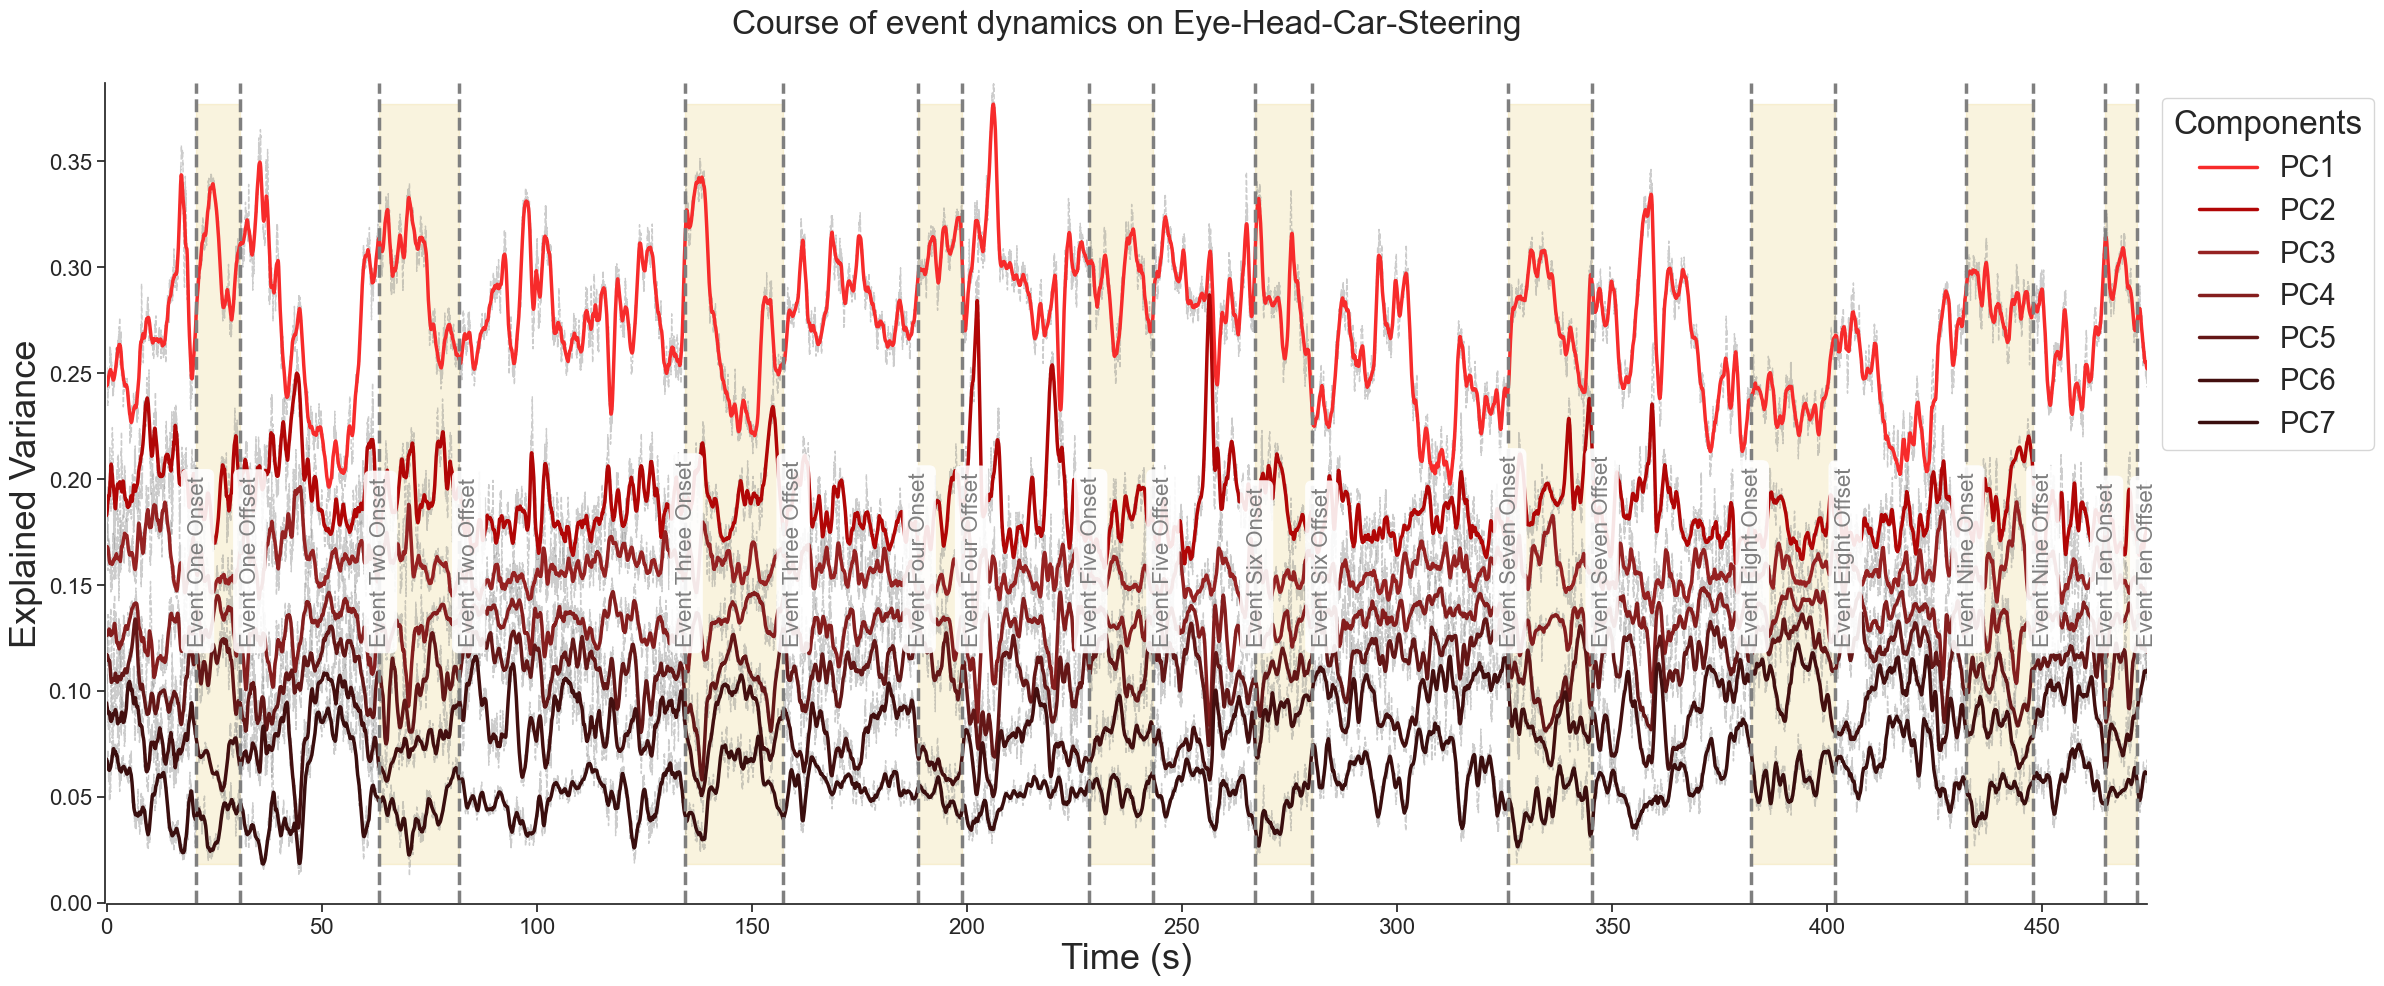

In [ ]:
save_path = 'results/variances/timeplot'
# visualize PCs variance over time
visualize_variance(
    variances_df,
    event='',
    save=True,
    title='Course of event dynamics on Eye-Head-Car-Steering',
    save_name=save_path,
    format='pdf'
)

Visualize variance for one event

Max variance: 23.74; Min variance: 28.66


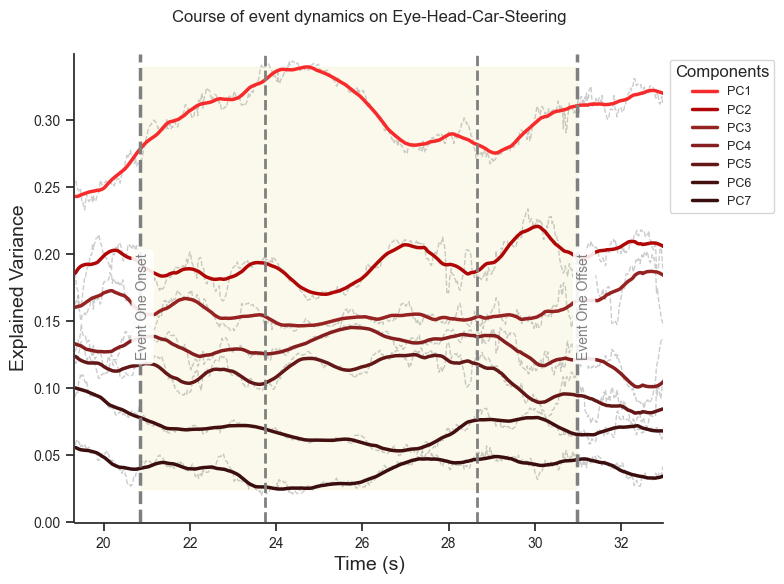

In [7]:
# visualize PCs variance over time
visualize_variance(
    variances_df,
    event='one', 
    save=False, 
    title = 'Course of event dynamics on Eye-Head-Car-Steering',
    save_name=save_path
)

# Average variance across PCs

In [8]:
# Calculate mean and std of PC1 and PC2 over the drive
print("Average variance and standard deviation of PC1 and PC2 over the drive:")
print(f"PC1 and PC2 mean and std: \n{variances_df[['PC1', 'PC2']].agg(['mean', 'std'])}")
# variances_df['PC2'].agg(['mean', 'std'])


Average variance and standard deviation of PC1 and PC2 over the drive:
PC1 and PC2 mean and std: 
           PC1       PC2
mean  0.273023  0.187775
std   0.032123  0.018601


In [9]:
# Define the list of events 
event_list = ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']

# Initialize empty DataFrames to collect results for all events
all_min_df = pd.DataFrame()
all_max_df = pd.DataFrame()

for event in event_list:
    _, min_event_df, max_event_df = segment_event(variances_df, event=event)
    # concat min and max dfs for each event
    all_min_df = pd.concat([all_min_df, min_event_df], ignore_index=True)
    all_max_df = pd.concat([all_max_df, max_event_df], ignore_index=True)

print(f"Max cumulative variance per event: \n{all_max_df}")
print(f"Min cumulative variance per event: \n{all_min_df}")

Max cumulative variance per event: 
     Time  Event     PC1-2
0   23.74    one  0.537757
1   70.18    two  0.553067
2  138.64  three  0.571918
3  197.50   four  0.540634
4  237.00   five  0.515562
5  268.48    six  0.528899
6  333.66  seven  0.517120
7  400.88  eight  0.471791
8  436.90   nine  0.513684
9  464.98    ten  0.529163
Min cumulative variance per event: 
     Time  Event     PC1-2
0   28.66    one  0.451084
1   80.42    two  0.436118
2  145.16  three  0.396934
3  189.14   four  0.450010
4  235.58   five  0.413039
5  280.18    six  0.413510
6  325.92  seven  0.416075
7  393.88  eight  0.380242
8  435.68   nine  0.434910
9  471.36    ten  0.436062


Now we extract the proportional variance by each PC at those timepoints

In [10]:
# Subset variances_df where 'Time' matches any value in all_min_df['Time']
subset_min = variances_df[variances_df['Time'].isin(all_min_df['Time'])][['Time', 'Event', 'PC1', 'PC2']].reset_index(drop=True)

# Similarly, for max
subset_max = variances_df[variances_df['Time'].isin(all_max_df['Time'])][['Time', 'Event', 'PC1', 'PC2']].reset_index(drop=True)

print("Subset of variances_df where Time matches all_max_df['Time']:\n", subset_max)
print("Subset of variances_df where Time matches all_min_df['Time']:\n", subset_min)

Subset of variances_df where Time matches all_max_df['Time']:
      Time  Event       PC1       PC2
0   23.74    one  0.339453  0.198305
1   70.18    two  0.336757  0.216310
2  138.64  three  0.344345  0.227573
3  197.50   four  0.325570  0.215064
4  237.00   five  0.321296  0.194266
5  268.48    six  0.309388  0.219511
6  333.66  seven  0.309504  0.207616
7  400.88  eight  0.270816  0.200975
8  436.90   nine  0.311225  0.202459
9  464.98    ten  0.325245  0.203919
Subset of variances_df where Time matches all_min_df['Time']:
      Time  Event       PC1       PC2
0   28.66    one  0.268287  0.182797
1   80.42    two  0.265858  0.170260
2  145.16  three  0.226766  0.170168
3  189.14   four  0.300325  0.149685
4  235.58   five  0.252346  0.160693
5  280.18    six  0.229912  0.183598
6  325.92  seven  0.232622  0.183453
7  393.88  eight  0.223596  0.156646
8  435.68   nine  0.274384  0.160526
9  471.36    ten  0.266358  0.169705


In [11]:
print(f"Average explained variance across all events at max:\n {subset_max[['PC1', 'PC2']].agg(['mean', 'std'])}")
print(f"Average explained variance across all events at min:\n {subset_min[['PC1', 'PC2']].agg(['mean', 'std'])}")

Average explained variance across all events at max:
            PC1       PC2
mean  0.319360  0.208600
std   0.021153  0.010596
Average explained variance across all events at min:
            PC1       PC2
mean  0.254046  0.168753
std   0.025309  0.011933


# Variance around event onset
Here, we segment principal component variances around all ten critical events before (BO) and after (AO) onset windows and apply chi-square test to test for a significant difference.

In [12]:
def vis_var_onset(variances_df: pd.DataFrame,
                  event_col: str = 'Event',
                  time_col: str = 'Time',
                  pcs: Optional[List[str]] = None,
                  window: float = 2,
                  save: bool = False,
                  save_name: str = 'pc_variances_around_event_onset',
                  around: str = 'onset') -> pd.DataFrame:
    """
    Visualize principal component variances (PC1..PC7) around event onset (or
    offset) and return a long-format dataframe aligned to that anchor,
    analogous to ED analysis.

    Input dataframe is expected to have columns: PC1..PC7 (or provided via
    `pcs`), plus `time_col` and `event_col`.
    """

    if pcs is None:
        # Default PCs from PC1..PC7 if present
        pcs = [c for c in variances_df.columns if c.upper().startswith('PC')]
        pcs = sorted(pcs, key=lambda x: int(''.join([ch for ch in x if ch.isdigit()]) or 0))

    # Identify unique event names
    unique_events = variances_df[~variances_df[event_col].str.contains('NoEv|BE|AF')][event_col].unique()
    # Anchor times: onsets are event changes vs previous; offsets are changes vs next
    event_onsets = variances_df.loc[variances_df[event_col] != variances_df[event_col].shift(), [time_col, event_col]]
    event_offsets = variances_df.loc[variances_df[event_col] != variances_df[event_col].shift(-1), [time_col, event_col]]
    anchor_df = event_onsets if str(around).lower() == 'onset' else event_offsets
    anchor_label = 'onset' if str(around).lower() == 'onset' else 'offset'

    # Prepare figure: single axes where all PCs are overlaid
    aligned_records: List[Dict[str, object]] = []
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.suptitle(f"PC variances around critical event {anchor_label} (±{window}s)", fontsize=14)

    # Distinct linestyles for PCs' mean traces
    base_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1))]
    # Color map per PC
    color_pca = {
        'PC1': '#F72B2B', 'PC2': '#B10606',
        'PC3': '#962222', 'PC4': '#851E1E',
        'PC5': '#641717', 'PC6': '#430F0F',
        'PC7': '#3A0E0E',
    }

    for i, pc in enumerate(pcs):
        time_series_list: List[pd.Series] = []
        all_segments = []
        for event in unique_events:
            anchors = anchor_df.loc[anchor_df[event_col] == event, time_col]
            for anchor_t in anchors:
                win = variances_df[(variances_df[time_col] >= anchor_t - window) & (variances_df[time_col] <= anchor_t + window)].copy()
                rel_t = win[time_col] - anchor_t
                all_segments.append(win[pc].reset_index(drop=True))
                time_series_list.append(rel_t.reset_index(drop=True))

                for rt, val in zip(rel_t, win[pc]):
                    aligned_records.append({
                        'event': event,
                        'relative_time': rt,
                        'PC': pc,
                        'value': val
                    })

        if len(all_segments) > 0:
            seg_df = pd.concat(all_segments, axis=1)
            mean_vals = seg_df.mean(axis=1)
            # Average relative time across all windows to obtain a representative grid
            if len(time_series_list) > 0:
                time_vals = pd.concat(time_series_list, axis=1).mean(axis=1)
            else:
                time_vals = pd.Series(np.linspace(-window, window, num=len(mean_vals)))
            # Standard error across event windows (per-timepoint)
            n_windows = float(seg_df.shape[1]) if seg_df.shape[1] > 0 else 1.0
            sem_vals = seg_df.std(axis=1) / np.sqrt(n_windows)
            # Plot mean (black, linestyle per PC)
            style = base_styles[i % len(base_styles)]
            line_color = color_pca.get(pc, 'k')
            ax.plot(time_vals, mean_vals, color=line_color, linestyle=style, linewidth=2, label=pc)
            # Plot ±1 SEM band using the same PC color with low alpha
            ax.fill_between(time_vals, mean_vals - sem_vals, mean_vals + sem_vals, color=line_color, alpha=0.1)

    # Anchor line and cosmetics
    ax.axvline(0, color='#7f7f7f', linestyle='--', linewidth=1.2, label=anchor_label.capitalize())
    ax.set_xlabel("Time (s)", fontsize=12)
    ax.set_ylabel("Variance", fontsize=12)
    ax.grid(False)
    # Ensure xlim is set to min and max, and ticks/labels are shown at those points
    ax.set_xlim(-window, window)
    xticks = np.linspace(-window, window, num=5)
    if xticks[0] != -window:
        xticks[0] = -window
    if xticks[-1] != window:
        xticks[-1] = window
    ax.set_xticks(xticks)
    # Ensure min and max are labeled
    labels = [f"{tick:.2f}" if tick in [-window, window] else f"{tick:.2f}" for tick in xticks]
    ax.set_xticklabels(labels)
    sns.despine(ax=ax, offset=10, trim=True)
    ax.spines['bottom'].set_bounds(-window, window)

    # Place legend outside to avoid clutter
    handles, labels = ax.get_legend_handles_labels()
    # Keep unique labels in order
    seen = set()
    uniq = []
    for h, l in zip(handles, labels):
        if l not in seen:
            uniq.append((h, l))
            seen.add(l)
    ax.legend(*zip(*uniq), bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    if save:
        path = "plots/pca_new/timeplots/"
        formatted_name = f"{save_name}.jpeg"
        plt.savefig(path + formatted_name, dpi=600, bbox_inches='tight')
    plt.show()

    aligned_df = pd.DataFrame(aligned_records)
    mask0 = np.isclose(aligned_df['relative_time'], 0.0)
    aligned_df = aligned_df.loc[~mask0].copy()
    aligned_df['Timepoint'] = np.where(aligned_df['relative_time'] < 0, 'BO', 'AO')
    # Drop onset_time if present to match requested schema
    if 'onset_time' in aligned_df.columns:
        aligned_df = aligned_df.drop(columns=['onset_time'])
    return aligned_df

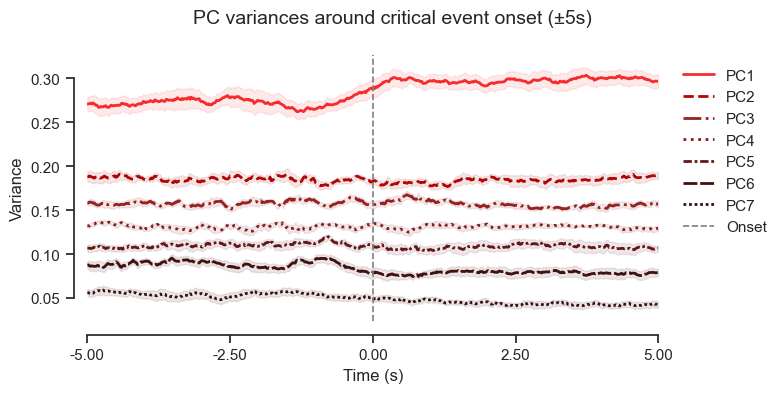

In [13]:
aligned_var = vis_var_onset(variances_df, window=5, around='onset')

In [14]:
aligned_var

,event,relative_time,PC,value,Timepoint
0,one,-5.00,PC1,0.302168,BO
1,one,-4.98,PC1,0.303319,BO
2,one,-4.96,PC1,0.303220,BO
3,one,-4.94,PC1,0.300710,BO
4,one,-4.92,PC1,0.290469,BO
...,...,...,...,...,...
35065,ten,4.92,PC7,0.054287,AO
35066,ten,4.94,PC7,0.054412,AO
35067,ten,4.96,PC7,0.054091,AO
35068,ten,4.98,PC7,0.054095,AO


In [15]:
mean_by_event_pc = aligned_var.groupby(['event', 'PC','Timepoint'])['value'].mean().reset_index()
mean_by_event_pc

,event,PC,Timepoint,value
0,eight,PC1,AO,0.241803
1,eight,PC1,BO,0.234179
2,eight,PC2,AO,0.176756
3,eight,PC2,BO,0.173558
4,eight,PC3,AO,0.155212
...,...,...,...,...
135,two,PC5,BO,0.099598
136,two,PC6,AO,0.065118
137,two,PC6,BO,0.077513
138,two,PC7,AO,0.044343


In [16]:
def plot_variance(df, save=False, save_name="variance_plot", format="png"):
    import plotly.graph_objects as go
    import pandas as pd

    fig = go.Figure()
    colors = {'BO': '#264653', 'AO': '#E4C65A'}

    # Step 1: Draw the main boxplots as before
    # We still keep boxmean=False to prevent the default mean line from appearing.
    for tp in ["BO", "AO"]:
        subset = df[df["Timepoint"] == tp]
        fig.add_trace(
            go.Box(
                x=subset["PC"],
                y=subset["value"],
                name=tp,
                boxpoints="all",
                pointpos=0,
                jitter=0.2,
                boxmean=False,
                whiskerwidth=0.2,
                fillcolor="white",
                marker=dict(
                    color=colors[tp],
                    size=5,
                    line=dict(color='black', width=0.9),
                    opacity=0.35,
                ),
                line=dict(color=colors[tp], width=1.8),
                offsetgroup=tp,
                alignmentgroup="timepoint",
                legendgroup=tp,
                showlegend=True,
            )
        )

    # Step 2: Add dashed black lines for the mean using fig.add_shape()
    # This is the new, corrected method. We removed the old workaround.
    means = df.groupby(['PC', 'Timepoint'])['value'].mean()
    
    # Create a map from PC name to its numerical index for positioning
    pcs = df["PC"].unique()
    pc_map = {pc: i for i, pc in enumerate(pcs)}
    
    # Get layout properties needed for positioning calculations
    boxgroupgap = 0.1

    for (pc, tp), mean_val in means.items():
        # Calculate the center of the box on the x-axis
        pc_index = pc_map[pc]
        # The offset moves the line left for 'BO' and right for 'AO'
        offset = (1 - boxgroupgap) / 4.0
        center = pc_index - offset if tp == 'BO' else pc_index + offset
        
        # Define the width of the mean line
        line_width_on_axis = 0.4
        x0 = center - (line_width_on_axis / 2)
        x1 = center + (line_width_on_axis / 2)
        
        # Add the line shape to the figure
        fig.add_shape(
            type="line",
            xref="x", yref="y",
            x0=x0, y0=mean_val,
            x1=x1, y1=mean_val,
            # The line dictionary for shapes *does* support the 'dash' property
            line=dict(
                color="red",
                width=2,
                dash="dot",
            )
        )


    fig.update_layout(
        title='', #"Variance by PCs and Time Point",
        xaxis_title="Principal Components",
        yaxis_title="Variance",
        plot_bgcolor="white",
        paper_bgcolor="white",
        showlegend=True,
        boxmode="group",
        boxgap=0.1,
        boxgroupgap=0.1, # This value is used in the calculation above
        width=800,
        height=500,
        legend=dict(
            traceorder="normal",
            x=0.90,           # move legend inside plot area (adjust as needed)
            y=1,
            xanchor="left",
            yanchor="top",
            bgcolor="rgba(255,255,255,0.7)",
            bordercolor="lightgray",
            borderwidth=1,
        ),
        xaxis=dict(
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=False,
            showgrid=False,
            showticklabels=True,
            ticks="outside",
            tickwidth=1,
            tickcolor="black",
            ticklen=6,
            zeroline=False,
            side="bottom",
        ),
        yaxis=dict(
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=False,
            showgrid=False,
            gridcolor="lightgray",
            showticklabels=True,
            ticks="outside",
            tickwidth=2,
            tickcolor="black",
            ticklen=5,
            zeroline=False,
            side="left",
            tickformat=".2f",  # Show two digits after the dot
        ),
    )

    if save:
        # Ensure the 'variances' folder exists
        # os.makedirs("variances", exist_ok=True)
        save_path = os.path.join("results/variances/", f"{save_name}.{format}")
        # Save the image in high quality by increasing scale (for PNG, SVG, etc.)
        fig.write_image(save_path, format=format, scale=5)

    return fig

In [19]:
plot_variance(mean_by_event_pc, save=True, format="pdf")

2026-02-04 11:37:01,158 - tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of <SystemMonitor: cpu: 3 memory: 64 MB fds: 26>>
Traceback (most recent call last):
  File "/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/tornado/ioloop.py", line 937, in _run
    val = self.callback()
          ^^^^^^^^^^^^^^^
  File "/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/distributed/system_monitor.py", line 168, in update
    net_ioc = psutil.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/psutil/__init__.py", line 2126, in net_io_counters
    rawdict = _psplatform.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 12] Cannot allocate memory


# Statistical test

In [398]:
def compute_event_pc_bo_ao_stats(
        df: pd.DataFrame,
        event_col: str = 'event',
        pc_col: str = 'PC',
        value_col: str = 'value',
        timepoint_col: str = 'Timepoint',
        relative_time_col: Optional[str] = 'relative_time'
) -> pd.DataFrame:
    """
    Aggregate BO/AO statistics for each event × PC pair:
      means, SDs, counts, SEMs, and standardized differences.
    Works directly on the long-format variance dataframe.
    """

    data = df.copy()
    # If a relative time column exists, drop onset samples at exactly 0
    if relative_time_col is not None and relative_time_col in data.columns:
        mask0 = np.isclose(data[relative_time_col], 0.0)
        data = data.loc[~mask0].copy()

    required_cols = {event_col, pc_col, timepoint_col, value_col}
    missing = [c for c in required_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    grouped = (
        data
        .groupby([event_col, pc_col, timepoint_col], observed=True)[value_col]
        .agg(count='count', mean='mean', std='std')
        .reset_index()
    )

    wide = grouped.pivot(index=[event_col, pc_col], columns=timepoint_col)
    wide.columns = [f"{stat}_{tp}" for stat, tp in wide.columns]
    wide = wide.reset_index()

    # Ensure columns exist
    for col in ['count_BO', 'count_AO', 'std_BO', 'std_AO', 'mean_BO', 'mean_AO']:
        if col not in wide.columns:
            wide[col] = np.nan

    n_bo = wide['count_BO'].astype(float)
    n_ao = wide['count_AO'].astype(float)
    wide['sem_BO'] = np.where(n_bo > 1.0, wide['std_BO'] / np.sqrt(n_bo), 0.0)
    wide['sem_AO'] = np.where(n_ao > 1.0, wide['std_AO'] / np.sqrt(n_ao), 0.0)

    wide['delta'] = wide['mean_AO'] - wide['mean_BO']
    denom = np.sqrt(np.square(wide['sem_AO']) + np.square(wide['sem_BO']))
    eps = np.finfo(float).eps
    denom = denom.replace(0.0, np.sqrt(eps))
    wide['denom'] = denom
    wide['z'] = wide['delta'] / wide['denom']
    wide['z2'] = np.square(wide['z'])

    cols = [
        event_col, pc_col,
        'mean_BO', 'mean_AO', 'std_BO', 'std_AO', 'count_BO', 'count_AO',
        'sem_BO', 'sem_AO', 'delta', 'denom', 'z', 'z2'
    ]
    for c in cols:
        if c not in wide.columns:
            wide[c] = np.nan
    return wide[cols]


def variance_weighted_chi_square_global(
        df: pd.DataFrame,
        event_col: str = 'event',
        pc_col: str = 'PC',
        value_col: str = 'value',
        timepoint_col: str = 'Timepoint',
        relative_time_col: Optional[str] = 'relative_time',
        min_n: int = 1
) -> Dict[str, object]:
    """
    Single omnibus chi-square across all event×PC pairs using the
    inverse-variance standardized differences between AO and BO variances.

    Returns a dictionary with a formatted p-value string and Δ̂ ± CI.
    """

    per_pair = compute_event_pc_bo_ao_stats(
        df=df,
        event_col=event_col,
        pc_col=pc_col,
        value_col=value_col,
        timepoint_col=timepoint_col,
        relative_time_col=relative_time_col
    )

    # Optionally drop pairs with too few samples
    mask_min = (per_pair['count_BO'] >= min_n) & (per_pair['count_AO'] >= min_n)
    valid = per_pair.loc[mask_min].dropna(subset=['denom', 'delta'])
    if valid.empty:
        return {
            'num_pairs': 0,
            'chi2': np.nan,
            'df': 0,
            'p_value': 'NA',
            'weighted_mean_diff': np.nan,
            'ci_lower': np.nan,
            'ci_upper': np.nan,
            'per_pair': per_pair
        }

    z2_sum = float(valid['z2'].sum())
    df_pairs = int(valid.shape[0])

    # Robust p-value computation with fallbacks
    log_p = chi2.logsf(z2_sum, df_pairs)
    p_source = 'scipy-chi2'
    if not np.isfinite(log_p):
        try:
            import mpmath as mp
            mp.mp.dps = 80
            a = df_pairs / 2.0
            x = z2_sum / 2.0
            Q = mp.gammainc(a, x, mp.inf) / mp.gamma(a)
            log_p = float(mp.log(Q))
            p_val = float(Q) if Q > 0 else 0.0
            neg_log10_p = float(-mp.log(Q) / mp.log(10))
            p_value_str = f"0.000 (<1e-{int(np.floor(neg_log10_p))})" if (p_val == 0.0 or neg_log10_p >= 3) else f"{p_val:.6f}"
            p_source = 'mpmath'
        except Exception:
            z_wh = ((z2_sum / df_pairs) ** (1.0 / 3.0) - (1 - 2.0 / (9.0 * df_pairs))) / np.sqrt(2.0 / (9.0 * df_pairs))
            log_p = norm.logsf(z_wh)
            tiny_log = np.log(np.finfo(float).tiny)
            p_val = float(np.exp(log_p)) if log_p > tiny_log else 0.0
            neg_log10_p = float(-log_p / np.log(10))
            p_value_str = f"0.000 (<1e-{int(np.floor(neg_log10_p))})" if p_val == 0.0 else f"{p_val:.6f}"
            p_source = 'wilson-hilferty'
    else:
        tiny_log = np.log(np.finfo(float).tiny)
        p_val = float(np.exp(log_p)) if log_p > tiny_log else 0.0
        neg_log10_p = float(-log_p / np.log(10))
        p_value_str = f"0.000 (<1e-{int(np.floor(neg_log10_p))})" if (p_val == 0.0 or neg_log10_p >= 3) else f"{p_val:.6f}"

    # Inverse-variance weighted mean difference and CI
    weights = 1.0 / np.square(valid['denom'])
    weighted_delta = float(np.sum(weights * valid['delta']) / np.sum(weights))
    se_weighted = float(1.0 / np.sqrt(np.sum(weights)))
    ci_low = weighted_delta - 1.96 * se_weighted
    ci_high = weighted_delta + 1.96 * se_weighted

    return {
        'num_pairs': df_pairs,
        'chi2': z2_sum,
        'df': df_pairs,
        'p_value': p_value_str,
        'weighted_mean_diff': weighted_delta,
        'ci_lower': float(ci_low),
        'ci_upper': float(ci_high),
        'per_pair': valid.reset_index(drop=True)
    }

In [470]:
res_var = variance_weighted_chi_square_global(aligned_var)

In [472]:
import numpy as np, re
# res_var is the dict returned by variance_weighted_chi_square_global(...)
p_txt = res_var['p_value']                     # e.g., '0.000 (<1e-138)' or '0.012345'
p_num = res_var.get('p_value_float', np.nan)   # may be missing/0.0; optional

eq = '='

# Optional: readable -log10 p summary
if np.isfinite(p_num) and p_num > 0:
    neglog10_txt = f"{-np.log10(p_num):.1f}"
else:
    m1 = re.search(r'<1e-(\d+)', p_txt)                 # from strings like '0.000 (<1e-138)'
    m2 = re.search(r'≈\s*([0-9.]+)e-([0-9]+)', p_txt)   # from strings like '0.000 (≈ 2.4e-08)'
    if m1:
        neglog10_txt = f">{m1.group(1)}"
    elif m2:
        neglog10_txt = f"{m2.group(2)}"
    else:
        neglog10_txt = "NA"

print(
    f"χ²({res_var['df']}, \x1b[3mN\x1b[0m = {res_var['num_pairs']}) = {res_var['chi2']:.2f}, "
    f"p {eq} {p_txt}, Δ̂ = {res_var['weighted_mean_diff']:.3f} "
    f"[{res_var['ci_lower']:.3f}, {res_var['ci_upper']:.3f}]"
)

# Optional: inspect per-pair (event×PC) components
res_var['per_pair']

χ²(70, N = 70) = 23051.27, p = 0.000 (<1e-4905), Δ̂ = -0.002 [-0.002, -0.002]


,event,PC,mean_BO,mean_AO,std_BO,std_AO,count_BO,count_AO,sem_BO,sem_AO,delta,denom,z,z2
0,eight,PC1,0.234179,0.241803,0.016875,0.007242,250,250,0.001067,0.000458,0.007624,0.001161,6.564571,43.093589
1,eight,PC2,0.173558,0.176756,0.011726,0.010829,250,250,0.000742,0.000685,0.003198,0.001010,3.167380,10.032294
2,eight,PC3,0.154254,0.155212,0.008279,0.006079,250,250,0.000524,0.000384,0.000958,0.000650,1.475234,2.176316
3,eight,PC4,0.135143,0.135916,0.006699,0.006624,250,250,0.000424,0.000419,0.000772,0.000596,1.296212,1.680165
4,eight,PC5,0.117097,0.124352,0.007846,0.006674,250,250,0.000496,0.000422,0.007255,0.000651,11.136468,124.020926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,two,PC3,0.163307,0.165844,0.010363,0.008004,250,250,0.000655,0.000506,0.002537,0.000828,3.062979,9.381838
66,two,PC4,0.121316,0.127955,0.012339,0.007199,250,250,0.000780,0.000455,0.006639,0.000903,7.347758,53.989554
67,two,PC5,0.099598,0.096004,0.011958,0.016107,250,250,0.000756,0.001019,-0.003594,0.001269,-2.832716,8.024277
68,two,PC6,0.077513,0.065118,0.011018,0.005764,250,250,0.000697,0.000365,-0.012395,0.000786,-15.760590,248.396205


## Variance redistribution across PCs

In [475]:
def variance_redistribution_across_pcs(
        df: pd.DataFrame,
        event_col: str = 'event',
        pc_col: str = 'PC',
        value_col: str = 'value',
        timepoint_col: str = 'Timepoint',
        relative_time_col: Optional[str] = 'relative_time'
) -> Dict[str, object]:
    """
    Test whether BO→AO changes differ across PCs (redistribution across PCs)
    using a single omnibus statistic:

      Q_pc = Σ_p w_p (Δ̂_p − Δ̂)^2,  df = P − 1

    where Δ̂_p is the inverse-variance weighted mean change for PC p across
    events, and w_p = Σ_i w_ip with w_ip = 1/(SEM_AO^2 + SEM_BO^2) for pair (i,p).

    Returns a dict with Q_pc, df, formatted p_value, I2_pc, and the global
    pooled Δ̂ ± CI. Also returns a per-PC table (Δ̂_p, CI) for reference.
    """

    # Build per-pair stats
    per_pair = compute_event_pc_bo_ao_stats(
        df=df,
        event_col=event_col,
        pc_col=pc_col,
        value_col=value_col,
        timepoint_col=timepoint_col,
        relative_time_col=relative_time_col
    )

    valid = per_pair.dropna(subset=['denom', 'delta']).copy()
    if valid.empty:
        return {
            'Q_pc': np.nan,
            'df': 0,
            'p_value': 'NA',
            'I2_pc': np.nan,
            'global_delta': np.nan,
            'global_ci_lower': np.nan,
            'global_ci_upper': np.nan,
            'per_pc': pd.DataFrame(columns=[pc_col, 'delta_hat', 'ci_lower', 'ci_upper', 'weight_sum'])
        }

    # weights per pair
    valid['w'] = 1.0 / np.square(valid['denom'])

    # Aggregate within each PC
    per_pc = (
        valid
        .groupby(pc_col, observed=True)
        .apply(lambda g: pd.Series({
            'weight_sum': g['w'].sum(),
            'delta_hat': float(np.sum(g['w'] * g['delta']) / np.sum(g['w']))
        }))
        .reset_index()
    )

    # Variance of delta_hat per PC and CI
    per_pc['se'] = (1.0 / np.sqrt(per_pc['weight_sum'].replace(0.0, np.finfo(float).eps))).astype(float)
    per_pc['ci_lower'] = per_pc['delta_hat'] - 1.96 * per_pc['se']
    per_pc['ci_upper'] = per_pc['delta_hat'] + 1.96 * per_pc['se']

    # Global pooled effect across PCs (same as across all pairs)
    W_total = per_pc['weight_sum'].sum()
    delta_global = float(np.sum(per_pc['weight_sum'] * per_pc['delta_hat']) / W_total)
    se_global = float(1.0 / np.sqrt(W_total))
    ci_gl_low = delta_global - 1.96 * se_global
    ci_gl_high = delta_global + 1.96 * se_global

    # Q statistic across PCs
    Q_pc = float(np.sum(per_pc['weight_sum'] * np.square(per_pc['delta_hat'] - delta_global)))
    P = per_pc.shape[0]
    df_pc = max(0, P - 1)

    # p-value formatting with robust fallbacks
    log_p = chi2.logsf(Q_pc, df_pc) if df_pc > 0 else np.nan
    p_val = np.nan
    if not np.isfinite(log_p):
        try:
            import mpmath as mp
            mp.mp.dps = 80
            a = df_pc / 2.0
            x = Q_pc / 2.0
            Q = mp.gammainc(a, x, mp.inf) / mp.gamma(a)
            log_p = float(mp.log(Q))
            p_val = float(Q) if Q > 0 else 0.0
            neg_log10_p = float(-mp.log(Q) / mp.log(10))
            p_value_str = f"0.000 (<1e-{int(np.floor(neg_log10_p))})" if (p_val == 0.0 or neg_log10_p >= 3) else f"{p_val:.6f}"
        except Exception:
            # Wilson–Hilferty approximation
            z_wh = ((Q_pc / df_pc) ** (1.0 / 3.0) - (1 - 2.0 / (9.0 * df_pc))) / np.sqrt(2.0 / (9.0 * df_pc))
            log_p = norm.logsf(z_wh)
            tiny_log = np.log(np.finfo(float).tiny)
            p_val = float(np.exp(log_p)) if log_p > tiny_log else 0.0
            neg_log10_p = float(-log_p / np.log(10))
            p_value_str = f"0.000 (<1e-{int(np.floor(neg_log10_p))})" if p_val == 0.0 else f"{p_val:.6f}"
    else:
        tiny_log = np.log(np.finfo(float).tiny)
        p_val = float(np.exp(log_p)) if log_p > tiny_log else 0.0
        neg_log10_p = float(-log_p / np.log(10))
        p_value_str = f"0.000 (<1e-{int(np.floor(neg_log10_p))})" if (p_val == 0.0 or neg_log10_p >= 3) else f"{p_val:.6f}"

    # I^2 across PCs
    I2_pc = float(max(0.0, (Q_pc - df_pc) / Q_pc) * 100.0) if (Q_pc > 0 and df_pc > 0) else 0.0

    # Order columns for per_pc output
    per_pc_out = per_pc[[pc_col, 'delta_hat', 'ci_lower', 'ci_upper', 'weight_sum']].copy()

    return {
        'Q_pc': Q_pc,
        'df': df_pc,
        'p_value': p_value_str,
        'p_value_float': float(p_val) if np.isfinite(p_val) else np.nan,
        'I2_pc': I2_pc,
        'global_delta': delta_global,
        'global_ci_lower': float(ci_gl_low),
        'global_ci_upper': float(ci_gl_high),
        'per_pc': per_pc_out
    }

In [476]:
res_redist = variance_redistribution_across_pcs(aligned_var, event_col='event', pc_col='PC',
                                                value_col='value', timepoint_col='Timepoint',
                                                relative_time_col='relative_time')

# print(f"Redistribution across PCs: Q({res_redist['df']}) = {res_redist['Q_pc']:.2f}, "
#       f"p = {res_redist['p_value']}, I^2 = {res_redist['I2_pc']:.1f}%")
# print(f"Global Δ̂ = {res_redist['global_delta']:.4f} "
#       f"[{res_redist['global_ci_lower']:.4f}, {res_redist['global_ci_upper']:.4f}]")

# # Optional: per-PC deltas
# res_redist['per_pc']

In [ ]:
import numpy as np, re

# res_redist is returned by variance_redistribution_across_pcs(...)
p_txt = res_redist['p_value']                   # e.g., '0.000 (<1e-138)' or '0.012345'
p_num = res_redist.get('p_value_float', np.nan) # may be missing/0.0

eq = '='

# Optional: readable -log10 p summary
if np.isfinite(p_num) and p_num > 0:
    neglog10_txt = f"{-np.log10(p_num):.1f}"
else:
    m1 = re.search(r'<1e-(\d+)', p_txt)
    m2 = re.search(r'≈\s*([0-9.]+)e-([0-9]+)', p_txt)
    if m1:
        neglog10_txt = f">{m1.group(1)}"
    elif m2:
        neglog10_txt = f"{m2.group(2)}"
    else:
        neglog10_txt = "NA"

P = res_redist.get('df', 0) + 1  # number of PCs

print(
    f"Q({res_redist['df']}, \x1b[3mP\x1b[0m = {P}) = {res_redist['Q_pc']:.2f}, "
    f"p {eq} {p_txt}, Δ̂ = {res_redist['global_delta']:.3f} "
    f"[{res_redist['global_ci_lower']:.3f}, {res_redist['global_ci_upper']:.3f}], "
    f"I^2 = {res_redist['I2_pc']:.1f}%"
)

# Optional: inspect per-PC effects
res_redist['per_pc']

Q(6, P = 7) = 7770.18, p = 0.000 (<1e-1680), Δ̂ = -0.002 [-0.002, -0.002], I^2 = 99.9%


,PC,delta_hat,ci_lower,ci_upper,weight_sum
0,PC1,0.026194,0.025491,0.026897,7.771530e+06
1,PC2,-0.001209,-0.001839,-0.000580,9.692973e+06
2,PC3,-0.002301,-0.002772,-0.001831,1.735634e+07
3,PC4,-0.000261,-0.000681,0.000160,2.173104e+07
4,PC5,-0.002601,-0.003123,-0.002079,1.409565e+07
5,PC6,-0.008049,-0.008487,-0.007611,2.003651e+07
6,PC7,-0.007032,-0.007384,-0.006681,3.106148e+07
